In [ ]:
%pip install deepcell python-dotenv

In [19]:
import os
from pathlib import Path
from dotenv import load_dotenv

env_path = Path.cwd() / '.env'
if not env_path.exists():
    env_path = Path.cwd() / 'Cell_Segmentation' / '.env'
load_dotenv(env_path)

if not os.getenv('DEEPCELL_ACCESS_TOKEN'):
    raise RuntimeError('DEEPCELL_ACCESS_TOKEN was not found in .env')


In [4]:
from deepcell.datasets import TissueNet

tissuenet = TissueNet(version='1.1')

INFO:root:Checking for cached data
INFO:root:Making request to server
INFO:root:Downloading data/tissuenet/tissuenet_v1-1.zip with size 4.1 GB to C:\Users\asus\.deepcell\datasets
4.08GB [03:54, 18.7MB/s]                             
INFO:root:🎉 Successfully downloaded file to C:\Users\asus\.deepcell\datasets\tissuenet_v1-1.zip
INFO:root:Extracting C:\Users\asus\.deepcell\datasets\tissuenet_v1-1.zip
INFO:root:Successfully extracted C:\Users\asus\.deepcell\datasets\tissuenet_v1-1.zip into C:\Users\asus\.deepcell\datasets


In [1]:
import os

import numpy as np
import skimage.io as io

from deepcell.utils.plot_utils import create_rgb_image
from deepcell.utils.plot_utils import make_outline_overlay

npz_dir = r"C:\Users\asus\.deepcell\datasets\tissuenet_v1-1"
train_dict = np.load(os.path.join(npz_dir, 'train.npz'),allow_pickle=True)
val_dict = np.load(os.path.join(npz_dir, 'val.npz'),allow_pickle=True)
test_dict = np.load(os.path.join(npz_dir, 'test.npz'),allow_pickle=True)


In [2]:
print(val_dict.keys())

KeysView(NpzFile 'C:\\Users\\asus\\.deepcell\\datasets\\tissuenet_v1-1\\val.npz' with keys: X, y, meta)


In [3]:
train_X, train_y, train_meta = train_dict['X'], train_dict['y'], train_dict['meta']
val_X, val_y, val_meta = val_dict['X'], val_dict['y'], val_dict['meta']
test_X, test_y, test_meta = test_dict['X'], test_dict['y'], test_dict['meta']

In [4]:
print("train_X shape:", train_X.shape)
print("train_y shape:", train_y.shape)

print("val_X shape:", val_X.shape)
print("val_y shape:", val_y.shape)

print("test_X shape:", test_X.shape)
print("test_y shape:", test_y.shape)


train_X shape: (2580, 512, 512, 2)
train_y shape: (2580, 512, 512, 2)
val_X shape: (3118, 256, 256, 2)
val_y shape: (3118, 256, 256, 2)
test_X shape: (1324, 256, 256, 2)
test_y shape: (1324, 256, 256, 2)


In [5]:
index = np.random.randint(0, train_X.shape[0])

rgb_image = create_rgb_image(
    train_X[index:index + 1], channel_colors=['green', 'blue']
)
overlay_data_cell = make_outline_overlay(
    rgb_data=rgb_image, predictions=train_y[index:index + 1, ..., 0:1]
)
overlay_data_nuc = make_outline_overlay(
    rgb_data=rgb_image, predictions=train_y[index:index + 1, ..., 1:2]
)

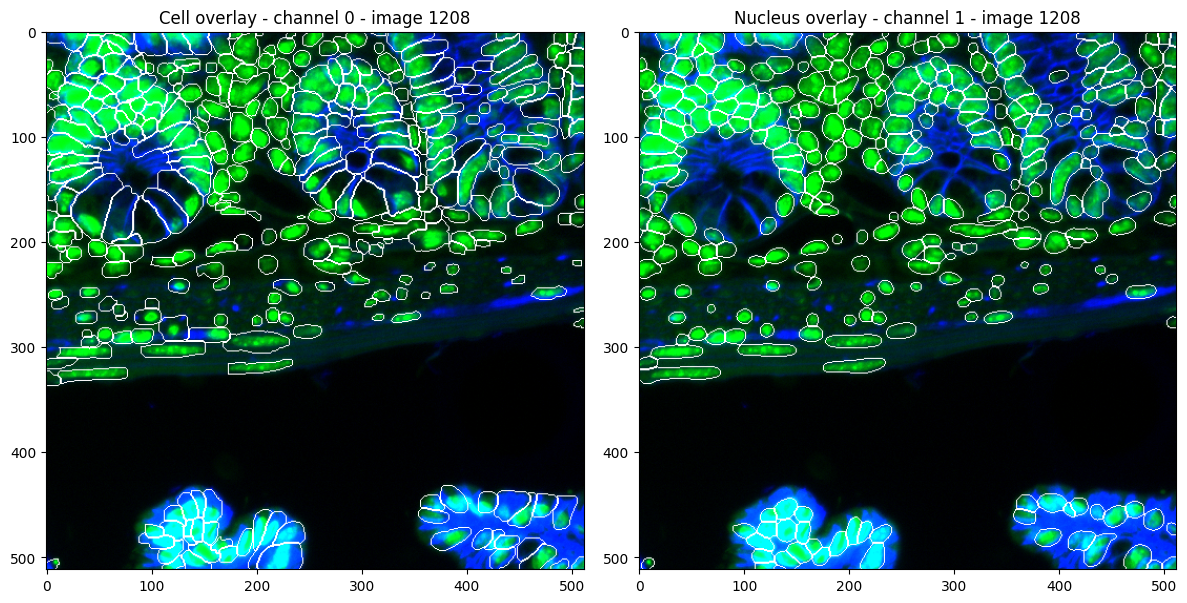

In [6]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 6))

axes[0].imshow(overlay_data_cell[0])
axes[0].set_title(f"Cell overlay - channel 0 - image {index}")

axes[1].imshow(overlay_data_nuc[0])
axes[1].set_title(f"Nucleus overlay - channel 1 - image {index}")

plt.tight_layout()
plt.show()

In [21]:
import pandas as pd

train_df = pd.DataFrame(train_meta[1:], columns=train_meta[0])

test_df = pd.DataFrame(test_meta[1:], columns=test_meta[0])
test_df = test_df.loc[3:,:].reset_index(drop=True)

val_df = pd.DataFrame(val_meta[1:], columns=val_meta[0])

In [40]:
train_specimens = set(train_df["specimen"])
val_specimens = set(val_df["specimen"])
test_specimens = set(test_df["specimen"])

print("train = val:", train_specimens == val_specimens)
print("train = test:", train_specimens == test_specimens)
print("val = test:", val_specimens == test_specimens)

train_df['specimen'].value_counts()

train = val: True
train = test: True
val = test: True


specimen
Pancreas                 606
Colon                    452
Breast                   379
Tonsil                   335
Esophagus                333
lymph node metastasis    295
Lymph Node                89
Epidermis                 86
Spleen                     4
Lung                       1
Name: count, dtype: int64

The specimen column in train, val and test dataset clearly shows taht Spleen and Lung are severely underrepresented compared with tissues such as Pancreas and Colon.

### Baseline A: use the whole training set for training.

In [5]:
import torch
from torch import nn, optim
from torch.utils.data import Dataset, DataLoader
from torchvision import datasets, transforms, models
import matplotlib.pyplot as plt
from IPython.display import clear_output
from torch.nn.functional import relu

In [6]:
class UNet(nn.Module):
    def __init__(self, n_class):
        super().__init__()

        # Encoder
        # input: 2x256x256
        self.e11 = nn.Conv2d(2, 64, kernel_size=3, padding=1)   # output: 64x256x256
        self.e12 = nn.Conv2d(64, 64, kernel_size=3, padding=1)  # output: 64x256x256
        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2)      # output: 64x128x128

        # input: 64x128x128
        self.e21 = nn.Conv2d(64, 128, kernel_size=3, padding=1)   # output: 128x128x128
        self.e22 = nn.Conv2d(128, 128, kernel_size=3, padding=1)  # output: 128x128x128
        self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2)        # output: 128x64x64

        # input: 128x64x64
        self.e31 = nn.Conv2d(128, 256, kernel_size=3, padding=1)  # output: 256x64x64
        self.e32 = nn.Conv2d(256, 256, kernel_size=3, padding=1)  # output: 256x64x64
        self.pool3 = nn.MaxPool2d(kernel_size=2, stride=2)        # output: 256x32x32

        # input: 256x32x32
        self.e41 = nn.Conv2d(256, 512, kernel_size=3, padding=1)  # output: 512x32x32
        self.e42 = nn.Conv2d(512, 512, kernel_size=3, padding=1)  # output: 512x32x32
        self.pool4 = nn.MaxPool2d(kernel_size=2, stride=2)        # output: 512x16x16

        # input: 512x16x16
        self.e51 = nn.Conv2d(512, 1024, kernel_size=3, padding=1)   # output: 1024x16x16
        self.e52 = nn.Conv2d(1024, 1024, kernel_size=3, padding=1)  # output: 1024x16x16

        # Decoder
        self.upconv1 = nn.ConvTranspose2d(1024, 512, kernel_size=2, stride=2)  # output: 512x32x32
        # concatenated with e42: 1024x32x32
        self.d11 = nn.Conv2d(1024, 512, kernel_size=3, padding=1)  # output: 512x32x32
        self.d12 = nn.Conv2d(512, 512, kernel_size=3, padding=1)   # output: 512x32x32

        self.upconv2 = nn.ConvTranspose2d(512, 256, kernel_size=2, stride=2)  # output: 256x64x64
        # concatenated with e32: 512x64x64
        self.d21 = nn.Conv2d(512, 256, kernel_size=3, padding=1)  # output: 256x64x64
        self.d22 = nn.Conv2d(256, 256, kernel_size=3, padding=1)  # output: 256x64x64

        self.upconv3 = nn.ConvTranspose2d(256, 128, kernel_size=2, stride=2)  # output: 128x128x128
        # concatenated with e22: 256x128x128
        self.d31 = nn.Conv2d(256, 128, kernel_size=3, padding=1)  # output: 128x128x128
        self.d32 = nn.Conv2d(128, 128, kernel_size=3, padding=1)  # output: 128x128x128

        self.upconv4 = nn.ConvTranspose2d(128, 64, kernel_size=2, stride=2)  # output: 64x256x256
        # concatenated with e12: 128x256x256
        self.d41 = nn.Conv2d(128, 64, kernel_size=3, padding=1)  # output: 64x256x256
        self.d42 = nn.Conv2d(64, 64, kernel_size=3, padding=1)   # output: 64x256x256

        # Output layer
        self.outconv = nn.Conv2d(64, n_class, kernel_size=1)  # output: n_classx256x256
        
    def forward(self, x):
        # Encoder
        xe11 = relu(self.e11(x))
        xe12 = relu(self.e12(xe11))
        xp1 = self.pool1(xe12)

        xe21 = relu(self.e21(xp1))
        xe22 = relu(self.e22(xe21))
        xp2 = self.pool2(xe22)

        xe31 = relu(self.e31(xp2))
        xe32 = relu(self.e32(xe31))
        xp3 = self.pool3(xe32)

        xe41 = relu(self.e41(xp3))
        xe42 = relu(self.e42(xe41))
        xp4 = self.pool4(xe42)

        xe51 = relu(self.e51(xp4))
        xe52 = relu(self.e52(xe51))
        
        # Decoder
        xu1 = self.upconv1(xe52)
        xu11 = torch.cat([xu1, xe42], dim=1)
        xd11 = relu(self.d11(xu11))
        xd12 = relu(self.d12(xd11))

        xu2 = self.upconv2(xd12)
        xu22 = torch.cat([xu2, xe32], dim=1)
        xd21 = relu(self.d21(xu22))
        xd22 = relu(self.d22(xd21))

        xu3 = self.upconv3(xd22)
        xu33 = torch.cat([xu3, xe22], dim=1)
        xd31 = relu(self.d31(xu33))
        xd32 = relu(self.d32(xd31))

        xu4 = self.upconv4(xd32)
        xu44 = torch.cat([xu4, xe12], dim=1)
        xd41 = relu(self.d41(xu44))
        xd42 = relu(self.d42(xd41))

        # Output layer
        out = self.outconv(xd42)

        return out

In [64]:
images = torch.randn(1, 2, 256, 256)
model = UNet(n_class=2)
output = model(images)

print(output.shape)

torch.Size([1, 2, 256, 256])


random croping training X and y to 256x256.

transform instance ID in training y to binary number.

In [7]:
def random_crop(image, label, crop_size=256):
    height, width = image.shape[:2]

    top = np.random.randint(0, height - crop_size + 1)
    left = np.random.randint(0, width - crop_size + 1)

    image = image[top:top + crop_size, left:left + crop_size, :]
    label = label[top:top + crop_size, left:left + crop_size, :]

    return image, label

In [8]:
class TissueNetDataset(Dataset):
    def __init__(self, images, labels, training=False, crop_size=256):
        self.images = images
        self.labels = labels
        self.training = training
        self.crop_size = crop_size

    def __len__(self):
        return len(self.images)

    def __getitem__(self, index):
        image = self.images[index]
        label = self.labels[index]

        if self.training:
            image, label = random_crop(image, label, self.crop_size)

        # Normalize each channel to [0, 1].
        image = image.astype(np.float32, copy=True)

        low = np.percentile(image, 1, axis=(0, 1), keepdims=True).astype(np.float32)
        high = np.percentile(image, 99, axis=(0, 1), keepdims=True).astype(np.float32)

        scale = np.maximum(high - low, np.float32(1e-6))
        np.subtract(image, low, out=image)
        np.divide(image, scale, out=image)
        np.clip(image, 0, 1, out=image)

        # Instance IDs -> binary masks.
        label = (label > 0).astype(np.float32)

        # HWC -> CHW.
        image = torch.from_numpy(np.ascontiguousarray(image.transpose(2, 0, 1))).float()
        label = torch.from_numpy(np.ascontiguousarray(label.transpose(2, 0, 1))).float()

        return image, label

In [9]:
train_dataset = TissueNetDataset(train_X, train_y, training=True)
val_dataset = TissueNetDataset(val_X, val_y, training=False)
test_dataset = TissueNetDataset(test_X, test_y, training=False)

batch_size = 2
train_dataloader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_dataloader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_dataloader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

In [114]:
batch_images, batch_targets = next(iter(train_dataloader))

print('images:', batch_images.shape, batch_images.dtype)
print('targets:', batch_targets.shape, batch_targets.dtype)
print('image range:', batch_images.min().item(), batch_images.max().item())
print('target values:', torch.unique(batch_targets))

model.eval()
with torch.no_grad():
    logits = model(batch_images)

print('model output:', logits.shape)
assert logits.shape == batch_targets.shape

images: torch.Size([1, 2, 256, 256]) torch.float32
targets: torch.Size([1, 2, 256, 256]) torch.float32
image range: 0.0 1.0
target values: tensor([0., 1.])
model output: torch.Size([1, 2, 256, 256])


In [10]:
device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")
print(f"Device: {device}")

Device: cuda


In [11]:
model = UNet(n_class=2).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
loss_fn = nn.BCEWithLogitsLoss()

In [12]:
def dice_score(logits, labels, threshold=0.5, eps=1e-6):
    probabilities = torch.sigmoid(logits)
    predictions = (probabilities >= threshold).float()

    # Calculate one Dice score per image across both output channels.
    dimensions = (1, 2, 3)
    intersection = (predictions * labels).sum(dim=dimensions)
    denominator = predictions.sum(dim=dimensions) + labels.sum(dim=dimensions)
    return (2 * intersection + eps) / (denominator + eps)


def train_one_epoch(dataloader, model, loss_fn, optimizer, device):
    model.train()

    total_loss = 0.0
    total_dice = 0.0
    total_images = 0

    for images, labels in dataloader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad(set_to_none=True)
        logits = model(images)
        loss = loss_fn(logits, labels)
        loss.backward()
        optimizer.step()

        current_batch_size = images.shape[0]
        total_loss += loss.item() * current_batch_size
        total_dice += dice_score(logits.detach(), labels).sum().item()
        total_images += current_batch_size

    average_loss = total_loss / total_images
    average_dice = total_dice / total_images
    return average_loss, average_dice

In [13]:
def evaluate(dataloader, model, loss_fn, device):
    model.eval()

    total_loss = 0.0
    total_dice = 0.0
    total_images = 0
    with torch.no_grad():
        for images, labels in dataloader:
            images = images.to(device)
            labels = labels.to(device)

            logits = model(images)
            loss = loss_fn(logits, labels)

            current_batch_size = images.shape[0]
            total_loss += loss.item() * current_batch_size
            total_dice += dice_score(logits, labels).sum().item()
            total_images += current_batch_size

    average_loss = total_loss / total_images
    average_dice = total_dice / total_images
    return average_loss, average_dice

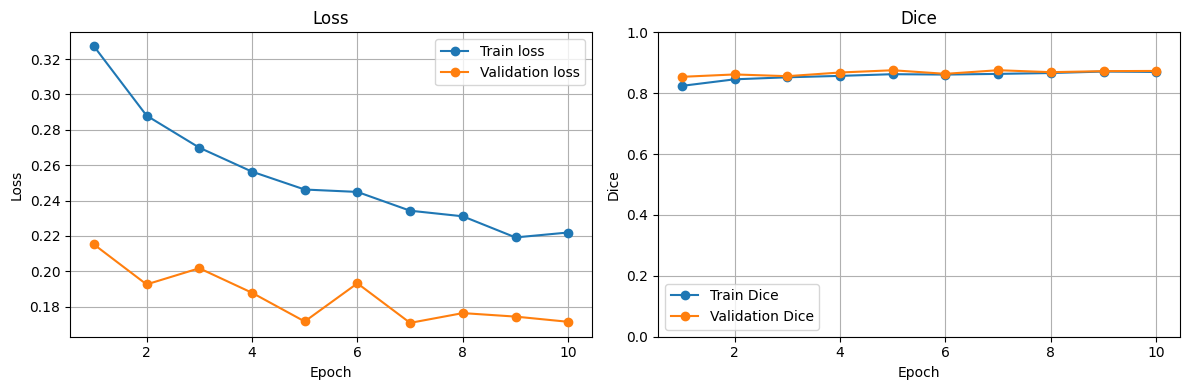

Epoch 10/10
Train loss: 0.2219, Train Dice: 87.0%
Validation loss: 0.1714, Validation Dice: 87.3%


In [14]:
epochs = 10

train_losses = []
train_dices = []
val_losses = []
val_dices = []
test_losses = []
test_dices = []


for epoch in range(epochs):
    train_loss, train_dice = train_one_epoch(train_dataloader, model, loss_fn, optimizer, device)
    val_loss, val_dice = evaluate(val_dataloader, model, loss_fn, device)

    train_losses.append(train_loss)
    train_dices.append(train_dice)
    val_losses.append(val_loss)
    val_dices.append(val_dice)

    clear_output(wait=True)

    epoch_range = range(1, epoch + 2)
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    axes[0].plot(epoch_range, train_losses, marker="o", label="Train loss")
    axes[0].plot(epoch_range, val_losses, marker="o", label="Validation loss")
    axes[0].set_title("Loss")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Loss")
    axes[0].legend()
    axes[0].grid(True)

    axes[1].plot(epoch_range, train_dices, marker="o", label="Train Dice")
    axes[1].plot(epoch_range, val_dices, marker="o", label="Validation Dice")
    axes[1].set_title("Dice")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Dice")
    axes[1].set_ylim(0, 1)
    axes[1].legend()
    axes[1].grid(True)

    plt.tight_layout()
    plt.show()

    print(f"Epoch {epoch+1}/{epochs}")
    print(f"Train loss: {train_loss:.4f}, Train Dice: {100*train_dice:.1f}%")
    print(f"Validation loss: {val_loss:.4f}, Validation Dice: {100*val_dice:.1f}%")